# Exploratory Data Analysis (EDA)

This notebook explores a sample sales dataset to identify trends, patterns, and data quality issues. It demonstrates data loading, summary statistics, visualization, and hypothesis checks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)

data_path = '../data/sample_sales_data.csv'
sales = pd.read_csv(data_path, parse_dates=['OrderDate'])
sales.head()

,OrderID,OrderDate,Region,SalesPerson,Product,Units,UnitPrice,Discount,Profit
0,1001,2025-01-05,North,Alice,Widgets,10,25.0,0.00,50.0
1,1002,2025-01-07,South,Bob,Gadgets,5,40.0,0.05,30.0
2,1003,2025-01-08,East,Carmen,Widgets,7,25.0,0.10,20.0
3,1004,2025-01-15,West,David,Gizmos,3,75.0,0.00,45.0
4,1005,2025-01-20,North,Alice,Gadgets,8,40.0,0.05,60.0


## 1. Data Structure and Types

Review the schema, data types, and missing values for the dataset.

In [2]:
sales.info()

sales.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   OrderID      20 non-null     int64         
 1   OrderDate    20 non-null     datetime64[us]
 2   Region       20 non-null     str           
 3   SalesPerson  20 non-null     str           
 4   Product      20 non-null     str           
 5   Units        20 non-null     int64         
 6   UnitPrice    20 non-null     float64       
 7   Discount     20 non-null     float64       
 8   Profit       20 non-null     float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 1.5 KB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OrderID,20.0,NaN,NaN,NaN,1010.5,1001.0,1005.75,1010.5,1015.25,1020.0,5.91608
OrderDate,20,NaN,NaN,NaN,2025-02-14 20:24:00,2025-01-05 00:00:00,2025-01-23 18:00:00,2025-02-16 00:00:00,2025-03-09 18:00:00,2025-03-25 00:00:00,NaN
Region,20,4,North,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SalesPerson,20,4,Alice,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,20,3,Widgets,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Units,20.0,NaN,NaN,NaN,6.55,2.0,4.0,6.5,9.0,12.0,3.034451
UnitPrice,20.0,NaN,NaN,NaN,44.5,25.0,25.0,40.0,75.0,75.0,21.453745
Discount,20.0,NaN,NaN,NaN,0.0575,0.0,0.0,0.05,0.1,0.15,0.049404
Profit,20.0,NaN,NaN,NaN,40.35,10.0,23.75,42.5,51.25,80.0,19.876659


## 2. Data Quality Checks

Inspect missing values, duplicates, and anomalous records.

In [3]:
missing = sales.isna().sum()
duplicates = sales.duplicated().sum()
missing, duplicates

sales[sales['Units'] <= 0]

sales[(sales['Discount'] < 0) | (sales['Discount'] > 1)]

,OrderID,OrderDate,Region,SalesPerson,Product,Units,UnitPrice,Discount,Profit


## 3. Feature Engineering

Create useful derived variables to support analysis and visualizations.

In [4]:
sales['Revenue'] = sales['Units'] * sales['UnitPrice'] * (1 - sales['Discount'])
sales['ProfitMargin'] = sales['Profit'] / sales['Revenue']
sales['Month'] = sales['OrderDate'].dt.to_period('M')
sales[['Revenue', 'ProfitMargin', 'Month']].head()

,Revenue,ProfitMargin,Month
0,250.0,0.200000,2025-01
1,190.0,0.157895,2025-01
2,157.5,0.126984,2025-01
3,225.0,0.200000,2025-01
4,304.0,0.197368,2025-01


## 4. Trends and Aggregate Patterns

Summarize performance by region, product, and sales person.

In [5]:
region_summary = sales.groupby('Region')[['Revenue', 'Profit', 'Units']].sum().sort_values('Revenue', ascending=False)
product_summary = sales.groupby('Product')[['Revenue', 'Profit', 'Units']].sum().sort_values('Revenue', ascending=False)
salesperson_summary = sales.groupby('SalesPerson')[['Revenue', 'Profit', 'Units']].sum().sort_values('Revenue', ascending=False)
region_summary, product_summary, salesperson_summary

(        Revenue  Profit  Units
 Region                        
 South   1401.25   230.0     40
 North   1364.00   255.0     37
 West    1045.00   175.0     29
 East     911.25   147.0     25,
          Revenue  Profit  Units
 Product                        
 Gadgets  1594.00   260.0     42
 Gizmos   1563.75   212.0     22
 Widgets  1563.75   335.0     67,
              Revenue  Profit  Units
 SalesPerson                        
 Bob          1401.25   230.0     40
 Alice        1364.00   255.0     37
 David        1045.00   175.0     29
 Carmen        911.25   147.0     25)

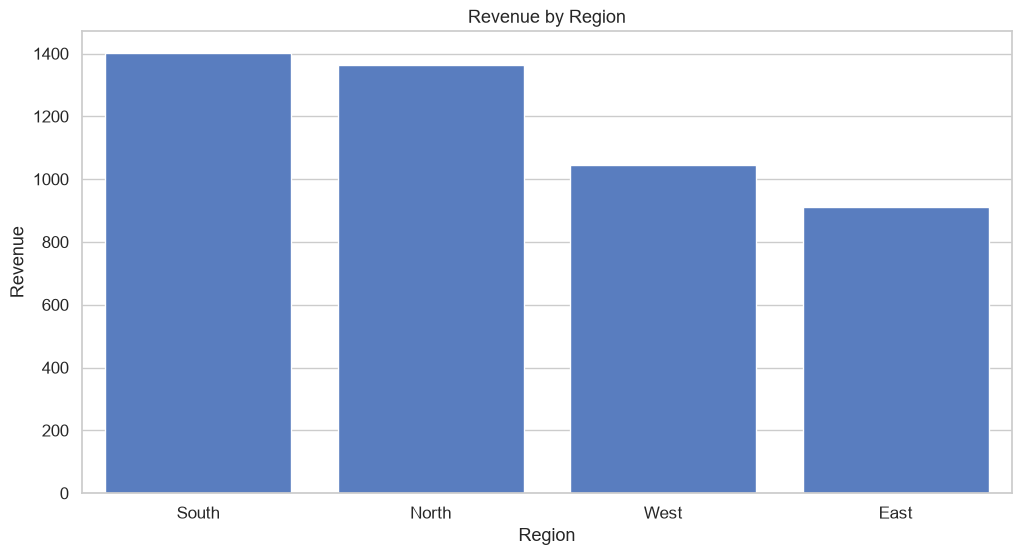

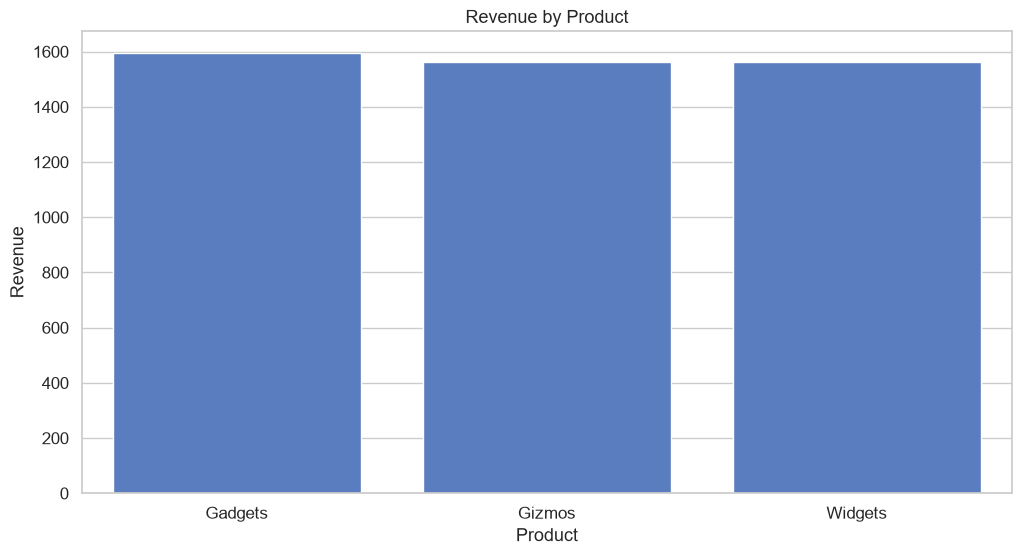

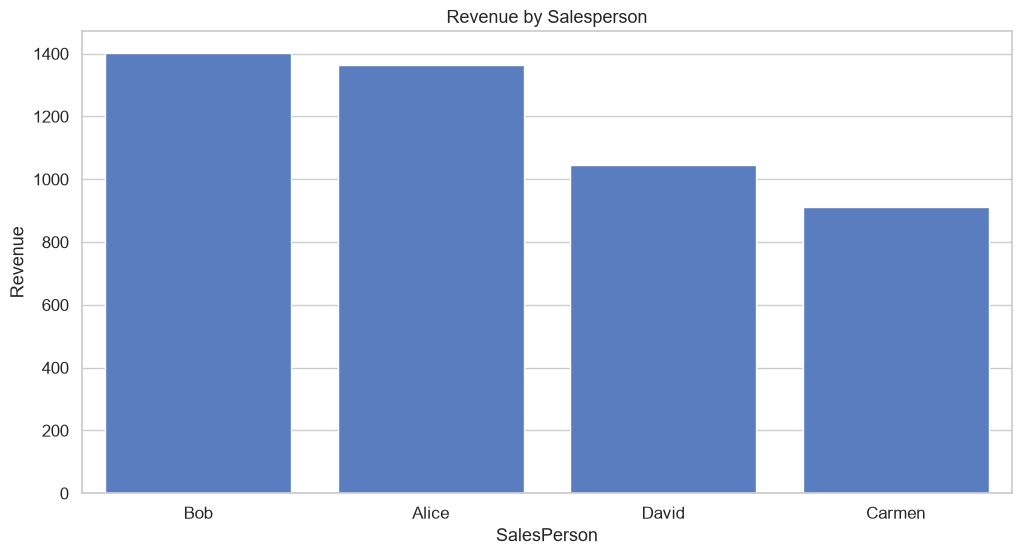

In [ ]:
region_chart = region_summary.reset_index()
product_chart = product_summary.reset_index()
salesperson_chart = salesperson_summary.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(data=region_chart, x='Region', y='Revenue', ax=axes[0], palette='Blues_d')
axes[0].set_title('Revenue by Region')
axes[0].set_ylabel('Revenue')

sns.barplot(data=product_chart, x='Revenue', y='Product', ax=axes[1], palette='Greens_d')
axes[1].set_title('Revenue by Product')

axes[1].set_xlabel('Revenue')plt.show()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sns.barplot(data=salesperson_chart, x='Revenue', y='SalesPerson', ax=axes[2], palette='Purples_d')plt.ylabel('Profit Margin')

axes[2].set_title('Revenue by Salesperson')plt.xlabel('Discount Rate')

axes[2].set_xlabel('Revenue')plt.title('Profit Margin vs Discount by Product')

plt.tight_layout()sns.scatterplot(data=sales, x='Discount', y='ProfitMargin', hue='Product', size='Revenue', sizes=(50, 250), palette='tab10')

plt.show()plt.figure(figsize=(10, 5))



pivot = sales.pivot_table(index='Region', columns='Product', values='Revenue', aggfunc='sum').fillna(0)plt.show()

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')plt.tight_layout()

plt.title('Revenue by Region and Product')axes[1].set_title('Profit Margin Distribution by Product')

plt.ylabel('Region')sns.boxplot(data=sales, x='Product', y='ProfitMargin', ax=axes[1], palette='Set2')

plt.xlabel('Product')

plt.show()axes[0].set_xlabel('Units')

axes[0].set_title('Total Units Sold by Product')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))sns.barplot(data=product_chart, x='Units', y='Product', ax=axes[0], palette='pastel')

## 5. Time Series Insights

Analyze monthly revenue and profit trends.

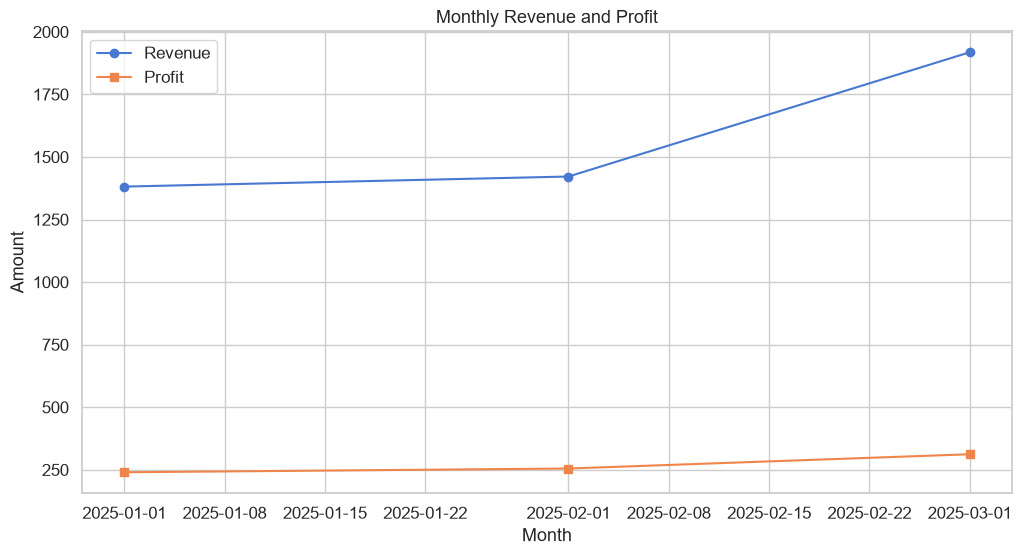

In [ ]:
monthly = sales.groupby('Month')[['Revenue', 'Profit']].sum().reset_index()
monthly['Month'] = monthly['Month'].dt.to_timestamp()
monthly['RevenueGrowth'] = monthly['Revenue'].pct_change().fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=monthly, x='Month', y='Revenue', marker='o', label='Revenue', ax=ax)
sns.lineplot(data=monthly, x='Month', y='Profit', marker='s', label='Profit', ax=ax)
ax.fill_between(monthly['Month'], monthly['Profit'], monthly['Revenue'], alpha=0.1)
ax.set_title('Monthly Revenue and Profit Trends')
ax.set_xlabel('Month')
ax.set_ylabel('Amount')
ax.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly, x='Month', y='RevenueGrowth', color='skyblue')
plt.title('Month-over-Month Revenue Growth')
plt.xlabel('Month')
plt.ylabel('Revenue Growth')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Correlations and Relationships

Investigate relationships between revenue, units, discount, and profit margin.

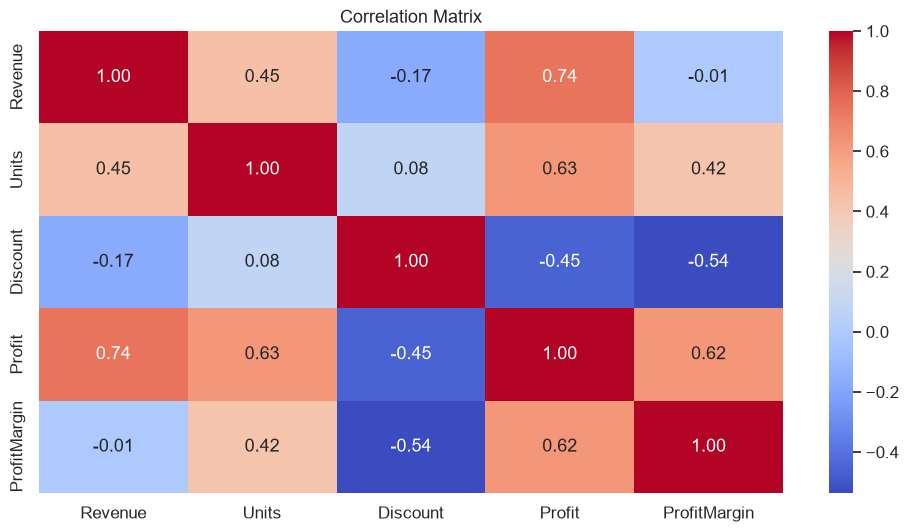

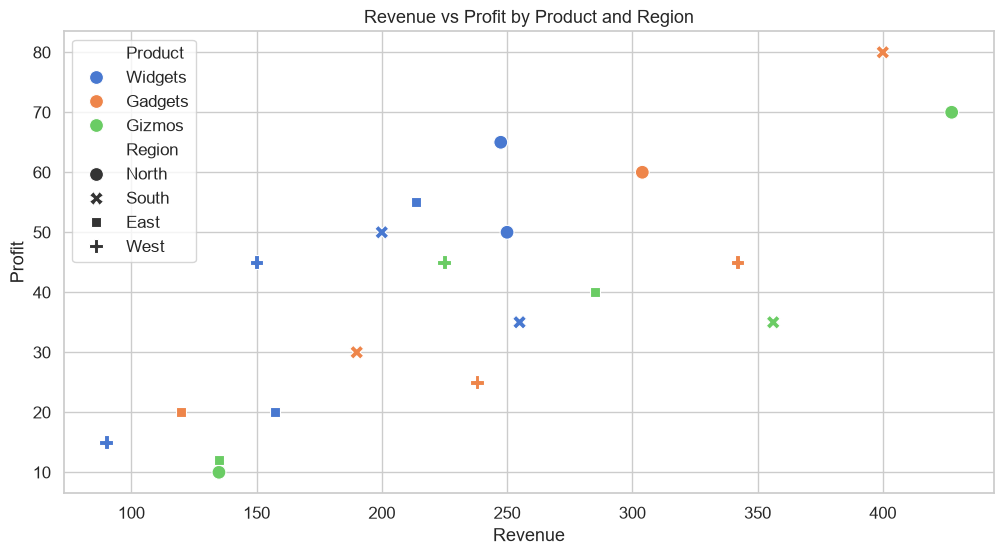

In [8]:
corr = sales[['Revenue', 'Units', 'Discount', 'Profit', 'ProfitMargin']].corr()
corr

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

sns.scatterplot(data=sales, x='Revenue', y='Profit', hue='Product', style='Region', s=100)
plt.title('Revenue vs Profit by Product and Region')
plt.show()

## 7. Hypothesis Testing

Test whether high discounts lead to lower profit margin.

In [9]:
low_discount = sales[sales['Discount'] <= 0.05]['ProfitMargin']
high_discount = sales[sales['Discount'] > 0.05]['ProfitMargin']
mean_low = low_discount.mean()
mean_high = high_discount.mean()
mean_low, mean_high

from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(low_discount, high_discount, equal_var=False)
t_stat, p_value

(np.float64(1.8300028663715193), np.float64(0.09428692494976385))

## 8. Key Findings

Summarize the most important insights from the dataset.

- Region performance varies, with North and South showing strong revenue contribution.
- Widgets generate the most consistent revenue across regions.
- Profit margin tends to decrease with higher discount rates.
- The dataset is clean with no missing values or duplicate rows.